# Implementing CNNs for image recognition.

In the last lab, we implemented an MLP to recognise handwritten digits. MLPs are very useful approximators but they don't have the ability to capture spatial information, because every input is considered the same way against every other input. Convolutional Neural Network (CNN), on the other hand, capture spatial information through convolution. It makes them more suitable to handle structured inputs, such as images.

As usual, we will approach this problem in three steps : defining the dataset, defining the model, and performing the optimization.

The dataset will still be the MNIST dataset, used to recognize handwritten digits.

## Setup the environement

We first setup the environnement and the necessary inputs as usual.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from tqdm import tqdm, trange
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix

## Dataset preparation

As in the last lab, we will prepare the data, preprocess it, and split it into train-test

In [2]:
# We load the dataset using the function load_digits
digits = load_digits()

## check the minimum and maximum value of a pixel in the dataset
print(f"Pixel values are between {np.min(digits.data)} and {np.max(digits.data)}")

processed_data = digits.data / 16

print(f"After normalization, pixel values are between {np.min(processed_data)} and {np.max(processed_data)}")

Pixel values are between 0.0 and 16.0
After normalization, pixel values are between 0.0 and 1.0


The cell above shows that our digits are actually flattened into a vector of dimension 64. We need 2D images to be able to process them through a CNN. In fact, 2D CNN layers expects input of the shape (C,H,W) where C is the number of channels, H is the height of the image, and W is the width of the image.
In our case, the MNIST data is grayscale, so it has C=1, and it's a collection of 8x8 images. So the shape the images should be (1,8,8).

In [3]:
## TODO : Reshape the images so that they can be input to a cnn layer.
## The data before reshaping is of shape N,64
## It should be of shape N, 1, 8, 8
processed_data = processed_data.reshape(-1, 1, 8, 8)

print(processed_data.shape) # should be 1797, 1, 8, 8 

(1797, 1, 8, 8)


We also need a train-test split. With 20% of the data set aside for testing.

In [4]:
## TODO : implement the train test split
def train_test_split(data, targets):
    N = len(data)
    indices = np.arange(N)
    np.random.shuffle(indices)
    
    train_indices = indices[:int(N*0.85)]
    test_indices = indices[int(N*0.85):]
    
    train_set = (data[train_indices], targets[train_indices])
    test_set = (data[test_indices], targets[test_indices])

    return train_set, test_set

train_set, test_set = train_test_split(processed_data, digits.target)

data_names = ["Train", "Test"]
data_sets = [train_set, test_set]
for name, (data, labels) in zip(data_names, data_sets):
    print(f"{name}:\t data={data.shape}, labels={labels.shape}")

Train:	 data=(1527, 1, 8, 8), labels=(1527,)
Test:	 data=(270, 1, 8, 8), labels=(270,)


### Validation split

The data is already split into a train and a test set. We will now introduce a new set that is also important for training : the validation set.

The validation set is an important set for training a model. It's a portion of the train set that we reserve aside to monitor the model's performance during training. It helps identify overfitting (when the model performs well on training data but poorly on new data) and provides a way to choose the best version of the model before final testing. This ensures that the model performs well on real-world data.

Typically, we reserve 20% of the train set for validation.

In [5]:
## TODO : split the train set into train-validation.
## Hint : it's very similar to a train-test split
def train_val_split(data, targets):
    N = len(data)
    indices = np.arange(N)
    np.random.shuffle(indices)
    
    train_indices = indices[:int(N*0.8235)]
    val_indices = indices[int(N*0.8235):]
    
    train_set = (data[train_indices], targets[train_indices])
    val_set = (data[val_indices], targets[val_indices])

    return train_set, val_set

train_set, val_set = train_val_split(*train_set)

data_names = ["Train", "Test", "Val"]
data_sets = [train_set, test_set, val_set]
for name, (data, labels) in zip(data_names, data_sets):
    print(f"{name}:\t data={data.shape}, labels={labels.shape}")
        
        

Train:	 data=(1257, 1, 8, 8), labels=(1257,)
Test:	 data=(270, 1, 8, 8), labels=(270,)
Val:	 data=(270, 1, 8, 8), labels=(270,)


## Implementation of the convolutional neural network.

### Forward pass

A 2D Conv Layer takes as input a 2D image and outputs a feature map by running filters on the image. More details and visualization [here](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53)

A conv layer has parameters that govern its behaviour : 
- The kernel size or size of the filter, a standard size is 3x3.
- The number of filters, this will determine the number of output feature maps.
- The stride, it controls how much pixels should the filter jump when computing the next value.

You can also add padding around the image if you want the output feature map to have the same dimension as the input.

For example suppose we have ConvLayer with 10 filters of size $5\times5$, that receives an input with 3 channels : 
- The number of parameter per filter is : $5 \times 5 \times 3$ : filter_size $\times$ input_channels.
- The number of output feature maps is $10$ : the number of filters.

Each of the 10 filters slides over the input image, computing a dot product between the filter's weights and the corresponding region of the input image.

We can write the computation of a convolution layer for an image patch $x$ as : 
$$ y = F \circledast x + b$$

Where $x$ is a patch of the same size as the filter $F$, $y$ is a pixel value and $b$ is the bias of the filter. $\circledast $ is the convolution operation.

### Backward pass

We now need to compute the gradient of the convolution operation to update the filter weight and the bias. For this layer we need to compute three gradients :
$$ \frac{d\mathcal{L}}{dx} $$
Where $y$  is the output feature map and $x$ is the input.
$$ \frac{d\mathcal{L}}{dF} $$
Where $F$ is the filter tensor (size filter_size_x $\times$ filter_size_y $\times$ input_channels)
$$ \frac{d\mathcal{L}}{db} $$
Where $b$ is the bias of the filter.



We give the expressions of the gradients here :
$$ \frac{d\mathcal{L}}{db_i} =  \sum_{j}\frac{d\mathcal{L}}{dy_{ij}} $$
Where $b_i$ is the bias of filter $i$ and y_{i} is the $i'th$ channel of the output $y$. We sum over all the pixels.
$$ \frac{d\mathcal{L}}{dF} = x \circledast \frac{d\mathcal{L}}{dy}$$
$$ \frac{d\mathcal{L}}{dx} = F^* \circledast pad(\frac{d\mathcal{L}}{dy}, x)$$

Where $F^*$ is the filter $F$ rotated by $180°$ and $pad(a,b)$ is a function that pads a to match the size of b. 

Similarly to last time, we will implement the convolutional layer. We provide a structure consistent with the previous lab's implementation, but you can come up with your own.

Convolution is more difficult to implement. You can start by implementing a convolution function that computes one pixel given a window of the same size of the filter, and then apply it to each window.
The stride and padding are optional.

You can also start with one filter, and then apply the same function to every filter to get all the feature maps.

In [6]:
## TODO : implement the pixel convolution operation.
def pixel_convolution(region, filter, bias):
    """This function implements the convolution operation between the filter and the 
    region of the image given as input.
    The region and the filter should have the exact same shape. The bias is a scalar value.
    The output should be a scalar value that represents the pixel being computed."""
    assert region.shape == filter.shape, F"Shape Mismatch: region {region.shape}, filter {filter.shape}"
    return np.sum(filter * region) + bias

## TODO : implements the convolution filter. 
class ConvolutionFilter : 
    """This class implements a single convolution filter. 
    It takes as input a feature map of
    size (C, H, W) and run its filter of size (C, kernel_size, kernel_size) over it.
    The output is of size (1, H-kernel_size+1, W-kernel_size+1)"""

    def __init__(self, input_dim, kernel_size, stride, pad_size) -> None:
        self.weights = np.random.randn(input_dim, kernel_size, kernel_size)
        self.bias = np.zeros(1)
        
        self.grad_w = np.zeros_like(self.weights)
        self.grad_b = np.zeros_like(self.bias)
        
        self.kernel_size = kernel_size
        self.stride = stride
        self.pad_size = pad_size
        self.cache = None
    
    def forward(self, x) : 
        """x is a feature map of size (C, H, W), the convolution filter should slide over the
        image and compute the pixel convolution for the output map.
        The output map should have size 1, H-kernel_size+1, W-kernel_size+1"""
        _, H, W = x.shape 
        
        if self.pad_size: 
            x = np.pad(x, ((0, 0), (1, 1), (1, 1)))
            h_out, w_out = H, W
        else:
            h_out = (H - self.kernel_size) // self.stride + 1
            w_out = (W - self.kernel_size) // self.stride + 1

        output = np.zeros((1, h_out, w_out))
        
        for i in range(h_out):
            for j in range(w_out):
                h_start = i * self.stride
                h_end = h_start + self.kernel_size
                w_start = j * self.stride
                w_end = w_start + self.kernel_size
                
                region = x[:, h_start:h_end, w_start:w_end]
                output[:, i, j] = pixel_convolution(region, self.weights, self.bias)
        
        self.cache = x
        
        return output

    def backward(self, dLdy): 
        """This function takes as input the derivative with respect to the output of this filter,
        and the input of this filter, and performs the backward propagation for this filter.
        It should compute 3 values : 
                - the derivative with respect to the bias.
                - the derivative with respect to the filter.
                - the derivative with respect to the input x.
        You are given indications in comments to help you through it."""
        
        if len(dLdy.shape) < 3:
            dLdy = dLdy.reshape(1, dLdy.shape[0], dLdy.shape[1])
        
        _, H, W = dLdy.shape
        
        ## Derivative with respect to bias, its a scalar (see formula)
        dLdb = np.sum(dLdy)

        ## Derivative with respect to weights/input
        ## It should have the same shape as the filter/input
        dLdw = np.zeros_like(self.weights, dtype=np.float32)
        dLdx = np.zeros_like(self.cache, dtype=np.float32)
            
        ## TODO : compute the derivative with respect to the weight. 
        # it is essentially a convolution between the input  
        # and the derivative of the output
        ## TODO : compute the derivative with respect to the input.
        # it is essentially a convolution between the filter rotated by 180 degrees (use np.flip)
        # and the derivative of the output.
        # don't forget to PAD the derivative to get the exact shape. (np.pad)
        
        weights_flipped = np.flip(self.weights, axis=(1, 2))

        if self.pad_size == 0:
            dLdy = np.pad(dLdy, pad_width=((0, 0), (1, 1), (1, 1)))

        for i in range(H):
            for j in range(W):
                h_start = i * self.stride
                h_end = h_start + self.kernel_size
                w_start = j * self.stride
                w_end = w_start + self.kernel_size
                
                region = self.cache[:, h_start:h_end, w_start:w_end]
                dLdw += dLdy[:, i, j] * region
                
                dLdx[:, h_start:h_end, w_start:w_end] += weights_flipped * dLdy[:, i, j]  
                
        if self.pad_size:
            dLdx = dLdx[:, self.pad_size:-self.pad_size, self.pad_size:-self.pad_size]
        
        ## TODO : save your gradient for step return the derivative wrt the input
        self.grad_w = dLdw
        self.grad_b= dLdb
        
        return dLdx
    
    def step(self, lr) :
        self.weights -= lr * self.grad_w
        self.bias -= lr * self.grad_b
        
        self.grad_w = np.zeros_like(self.weights)
        self.grad_b = np.zeros_like(self.bias)
    
    def __call__(self, x):
        return self.forward(x)

We give below the implementation of a 2D convolution layer using the ConvolutionFilter implemented above.

In [7]:
class Convolution2DLayer :
    """This implements the 2D convolution layer, it takes as input a matrix and runs its filters."""
    def __init__(self, input_dim, kernel_size, num_filters, stride=1, padding="valid"): 
        self.input_dim = input_dim
        self.num_filter = num_filters
        self.pad_size = 1 if padding == "same" else 0        
        self.cache = None

        
        self.filters = []
        for f in range(num_filters): 
            self.filters.append(ConvolutionFilter(input_dim, kernel_size, stride, self.pad_size))
        
    def forward(self, x):
        """This is the forward pass, to compute the output y_pred given the input.
        It computes the output of each filter and stacks them together"""
        self.cache = x
        
        y = []
        for f in self.filters : 
            y.append(f(x))
        
        
        y = np.stack(y).squeeze(axis=1)
        return y
    
    def backward(self, grad):
        """The backward pass allows you to compute the gradient of this layer"""
        dLdx = np.zeros_like(self.cache, dtype=np.float32)
        for i, f in enumerate(self.filters) :
            dLdx += f.backward(grad[i]) 
        return dLdx
    
    def step(self, lr):
        """Take a gradient descent step"""
        for f in self.filters : 
            f.step(lr)

    def __call__(self, x) : 
        """To ensure we can call this module."""
        return self.forward(x)

We need an activation function for our convolution layer. Sigmoid is a possible choice but we will use ReLU (rectified Linear Unit). The reLU function is defined as follows : 

$$ ReLU(x) = max(0, x) $$

It's a simple non-linear function that outputs 0 if $x$ is negative, and $x$ otherwise. Its derivative with respect to x is :
$$ ReLU'(x) = \mathbf{1}(x > 0) $$

In [8]:
## TODO : implement relu function and layer forward/backward
def relu(x):
    return np.maximum(0, x)

class ReLULayer : 
    """This implements the ReLU layer"""
    
    def __init__(self):
        self.cache = None

    def forward(self, x):
        """This is the forward pass, computes the reLU"""
        self.cache = x
        return relu(x)
    
    def backward(self, grad):
        """Computes the gradient of relu for backpropagation.
        Hint : there is no parameter, so only the gradient w.r.t the input is necessary"""
        return grad * (self.cache > 0).astype(float)

    def step(self, lr):
        pass # No parameters to update
    
    def __call__(self, x):
        return self.forward(x)

#### Pooling

The last layer we will implement is a pooling layer. A pooling layer takes as input a feature map and returns a new, downsized feature map, where each pixel is the max (for maxpooling) or the average (for average pooling) of the corresponding window in the input.

For example, if the image is of size $10\times 10$, a pooling layer of window size $2\times2$ will produce an output feature map of size $5\times5$.

Pooling layers are useful for downsampling the feature maps and working with smaller size input, which improves the computational efficiency of the model.

In [9]:
## TODO : implement a max pooling layer
class MaxPoolingLayer : 
    """This implements the pooling layer.
    You can focus on pooling layers with a window size of 2, as they
    are the typical values we use. 
    A pooling layer works by sliding its window over the input and taking the 
    max value of the pixel in that window. """
    
    def __init__(self, window_size):
        self.window_size = window_size
        self.cache = None
        self.argmax_cache = None

    def forward(self, x):
        """This is the forward pass, computes the pooling.
        For an input of size (C, H, W), it should (in case of window_size = 2)
        return an output of size (C, H//2, W//2) where each value is the max of a window of 
        2 pixels ran every 2 pixels."""
        C, H, W = x.shape
        h_out = H // self.window_size
        w_out = W // self.window_size
        
        output = np.zeros((C, h_out, w_out))
        self.argmax_cache = np.zeros_like(output, dtype=np.int64)
        
        for c in range(C):
            for i in range(h_out):
                for j in range(w_out):
                    region = x[c, i : i + self.window_size, j : j + self.window_size]
                    output[c, i, j] = np.max(region)
                    self.argmax_cache[c, i, j] = np.argmax(region.flatten())
            
        self.cache = x
        return output
    
    def backward(self, dLdy):
        """Computes the gradient of pooling for backpropagation.
        Hint : there is no parameter, so only the gradient w.r.t the input is necessary."""
        
        ## TODO : Compute the gradient with respect to the input, the size is supposed to be the 
        # size of the input of the forward propagation
        C, H, W = self.cache.shape
        h_out = H // self.window_size
        w_out = W // self.window_size
        
        ## No operation has been done apart from taking the max. This means that for every window,
        # the values that have not been taken should have a gradient of 0
        # while the values that has been taken by the pooling should have a gradient of 1
        dLdx = np.zeros_like(self.cache, dtype=np.float32)

        for c in range(C):
            for i in range(h_out):
                for j in range(w_out):
                    max_idx = self.argmax_cache[c, i, j]
                    h_idx = i * self.window_size + (max_idx // self.window_size)
                    w_idx = j * self.window_size + (max_idx % self.window_size)

                    dLdx[c, h_idx, w_idx] += dLdy[c, i, j]
        
        return dLdx

    def step(self, lr):
        pass # No parameters to update
    
    def __call__(self, x):
        return self.forward(x)

Since we are in a classification problem, we need to be able to output a vector of probabilities for each class. This is a 1D output, while our input is 2D.
We thus need to use a linear layer (or an MLP) at the end of our model to be able to transform the 2D input from the convolution layers to the desired output.

You can reuse your previous lab's implementation here for the linear layer. 

In [10]:
class LinearLayer :
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.randn(input_dim, output_dim) * 0.1
        self.bias = np.zeros(output_dim)
        self.grad_w = np.zeros_like(self.weights)
        self.grad_b = np.zeros_like(self.bias)
        self.cache = None
        
    def forward(self, x):
        self.cache = x
        return np.dot(x, self.weights) + self.bias
    
    def backward(self, grad):
        self.grad_w = np.dot(self.cache.T, grad)
        self.grad_b = np.sum(grad, axis=0)
        
        return np.dot(grad, self.weights.T)
    
    def step(self, lr):
        self.weights -= lr * self.grad_w
        self.bias -= lr * self.grad_b
        self.grad_w = np.zeros_like(self.weights)
        self.grad_b = np.zeros_like(self.bias)
        
    def __call__(self, x):
        return self.forward(x)                


In [11]:
## We give you a flatten layer to be able to pass from a 2D representation to a 1D representation 
# so you can use MLPs after CNN/pooling.
class FlattenLayer:
    def __init__(self):
        self.cache_shape = None
        
    def forward(self, x): 
        self.cache_shape = x.shape
        x = x.flatten().reshape(1, -1)
        self.x = x
        return x
    
    def backward(self, grad) : 
        grad = grad.reshape(*self.cache_shape)
        return grad

    def step(self, lr):
        pass # No parameters to update
    
    def __call__(self, x) :
        return self.forward(x)

Now that we have all the ingredients of our model, we can implement it.
Taking inspiration from the previous lab, implement the CNN class. It should take as input the description of your CNN layers, and the description of your MLP layers. Then it should compute the Convolution part, flatten the input, and compute the MLP part.

The output should be a vector of size 10 (we have 10 classes) exactly like the MLP lab.

In [12]:
## TODO : implement the full CNN

class CNN :
    """This implements the CNN, it's a combination of convolution layers 
    and linear layers to output the prediction for each class.
    It should implement CNN blocks, where each block is :
            - A Convolution layer
            - A Pooling Layer
            - An activation layer
    Then after all the blocks are implemented (1 is enough), it should use a flatten layer.
    Then once the data is flattened, you can use linear layers to produce the desired output.
    """
    def __init__(self, input_dims, CNN_layers, FC_layers, kernel_size=3, stride=1, padding="valid", window_size=2):
        """CNN_layer is a list like [2, 4, 5] and describe the number of filter in the Convolution layer per block.
        This particular example [2,4,5] means 3 blocks, the fist one with 2 filters, second one
        with 4 filters, third one with 5.
        FC layer describes the linear part similar to the MLP class in previous lab."""
        self.layers = []
        pad_size = 1 if padding == "same" else 0
        
        C, H, W = input_dims
        prev_dim = C
        h_out, w_out = H, W
        
        for num_filters in CNN_layers:
            self.layers.append(Convolution2DLayer(input_dim=prev_dim,
                                                  kernel_size=kernel_size,
                                                  num_filters=num_filters,
                                                  stride=stride,
                                                  padding=padding))
            if pad_size == 0: 
                h_out = ((h_out - kernel_size) // stride) + 1
                w_out = ((w_out - kernel_size) // stride) + 1
            
            self.layers.append(ReLULayer())
            self.layers.append(MaxPoolingLayer(window_size=window_size))
            h_out, w_out = h_out // 2, w_out // 2
            prev_dim = num_filters
        
        flatten_dim = prev_dim * h_out * w_out
        self.layers.append(FlattenLayer())

        FC_layers = [flatten_dim] + FC_layers
        for i in range(len(FC_layers) - 1):
            self.layers.append(LinearLayer(FC_layers[i], FC_layers[i + 1]))
            if i < len(FC_layers) - 2:
                self.layers.append(ReLULayer())
            
            
    def forward(self, x):
        """This is the forward pass, to compute the output y_pred given the input. 
        It should pass through the layers of the model"""
        for layer in self.layers:
            x = layer(x)
        return x 
    
    def backward(self, grad):
        """Computes the gradient of each layers"""
        grad = clip(grad)
        for layer in reversed(self.layers):
            grad = clip(layer.backward(grad))
        
        return grad

    def step(self, lr) :
        for layer in self.layers:
            layer.step(lr)
            
    
    def __call__(self, x):
        return self.forward(x)

    def copy(self):
        model_copy = CNN.__new__(CNN)
        model_copy.__dict__ = copy.deepcopy(self.__dict__)
        return model_copy


### Gradient clipping.

Because you are using ReLU instead of Sigmoid, there is a chance that you get the issue of exploding gradients. This happens because accumulating positive values will lead to the value of the gradient being higher and higher. This can hinder learning as it will make us take huge steps and miss our minimum. 

To alleviate this issue, we introduce gradient clipping. Where we clip the norm of the gradient to a set value if it becomes to big. A typical threshold for the gradient is 10.

In [13]:
## TODO : Implement the gradient clipping
def clip(value, clip_threshold=10): 
    return np.clip(value, -clip_threshold, clip_threshold)

## TODO : to make it effective, you need to modify the CNN class' backward method.
# to clip the gradient after every layer.

## Training procedure.

Since we are in a classification problem, the training procedure is the same as the previous lab. We will use cross entropy as our loss function.

Implement the training loop and train your model. Your code from the previous lab should work.

There is one modification, you should implement a `validation` loop that makes use of the validation dataset.

In [14]:
## TODO : implement the softmax function 
def softmax(x) :
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## TODO : implement the cross entropy
def cross_entropy(y_pred, y_true):
    return -np.sum(y_true * np.log(y_pred))

## TODO : implement the one hot function
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [15]:
# TODO : implement the training loop with the validation loop
def validation(model, val_data, val_labels, n_classes=10):
    """Validation loop : should go over all the validation data and compute
    the loss. The validation loss is the average of the loss over the data."""
    val_loss = 0.0
    
    for X, y in tqdm(zip(val_data, val_labels), desc="Validation"):
        val_true = one_hot(n_classes, y)
        logits = model(X)
        val_pred = softmax(logits)
        val_loss += cross_entropy(val_pred, val_true)
    val_loss /= len(val_data)
    
    return val_loss

def train(model, train_data, train_labels, val_data, val_labels, n_classes=10, lr=0.01, num_epochs=1):
    train_losses, val_losses = [], []
    best_model = None
    best_model_loss = float("inf")
    ## TODO : implement the train loop (similar to previous lab)
        ## TODO : every few epoch, call the validation loop and update the best model.
        ## The best model is the one that minimizes the validation loss.
    
    for epoch in trange(num_epochs, desc="Epochs"):
        epoch_loss = 0.0
        for X, y in tqdm(zip(train_data, train_labels), desc="Training"):
            y = one_hot(n_classes, y)
            logits = model(X)
            pred_probs = softmax(logits)
            loss = cross_entropy(pred_probs, y)
            epoch_loss += loss
            grad = pred_probs - y
            model.backward(grad)
            model.step(lr)

        epoch_loss /= len(train_data)
        train_losses.append(epoch_loss)
        
        val_loss = validation(model=model, val_data=val_data, val_labels=val_labels, n_classes=n_classes)
        val_losses.append(val_loss)
        
        if val_loss < best_model_loss:
            best_model_loss = val_loss
            best_model = model.copy()
        
        print(f"Epoch {epoch+1}/{num_epochs}: Train loss = {loss:.4f} | Val loss = {val_loss:.4f}\n\n")
    
    return train_losses, val_losses, best_model, best_model_loss

Epochs:   0%|                                                                                   | 0/20 [00:00<?, ?it/s]
Training: 0it [00:00, ?it/s]
Training: 1it [00:00,  8.89it/s]
Training: 2it [00:00,  8.89it/s]
Training: 3it [00:00,  8.74it/s]
Training: 5it [00:00,  9.74it/s]
Training: 7it [00:00, 10.38it/s]
Training: 9it [00:00, 11.40it/s]
Training: 11it [00:01, 11.76it/s]
Training: 13it [00:01, 11.38it/s]
Training: 15it [00:01, 11.38it/s]
Training: 17it [00:01, 11.46it/s]
Training: 19it [00:01, 10.71it/s]
Training: 21it [00:02,  9.65it/s]
Training: 23it [00:02, 10.60it/s]
Training: 25it [00:02, 11.75it/s]
Training: 27it [00:02, 12.40it/s]
Training: 29it [00:02, 12.89it/s]
Training: 31it [00:02, 13.24it/s]
Training: 33it [00:02, 13.90it/s]
Training: 35it [00:02, 14.26it/s]
Training: 37it [00:03, 14.43it/s]
Training: 39it [00:03, 14.51it/s]
Training: 41it [00:03, 14.51it/s]
Training: 43it [00:03, 14.10it/s]
Training: 45it [00:03, 14.37it/s]
Training: 47it [00:03, 14.87it/s]
Trainin

Training: 303it [00:32,  7.00it/s]
Training: 304it [00:32,  7.32it/s]
Training: 305it [00:32,  7.53it/s]
Training: 306it [00:32,  7.70it/s]
Training: 307it [00:32,  8.12it/s]
Training: 308it [00:32,  8.31it/s]
Training: 309it [00:32,  8.18it/s]
Training: 311it [00:33,  9.08it/s]
Training: 313it [00:33,  8.63it/s]
Training: 314it [00:33,  8.41it/s]
Training: 315it [00:33,  8.39it/s]
Training: 316it [00:33,  8.61it/s]
Training: 317it [00:33,  8.43it/s]
Training: 318it [00:33,  8.34it/s]
Training: 319it [00:34,  8.62it/s]
Training: 321it [00:34,  9.81it/s]
Training: 323it [00:34, 10.87it/s]
Training: 325it [00:34, 11.45it/s]
Training: 327it [00:34, 12.22it/s]
Training: 329it [00:34, 12.95it/s]
Training: 331it [00:34, 13.33it/s]
Training: 333it [00:35, 14.29it/s]
Training: 335it [00:35, 13.77it/s]
Training: 337it [00:35, 14.35it/s]
Training: 339it [00:35, 14.79it/s]
Training: 341it [00:35, 14.65it/s]
Training: 343it [00:35, 15.00it/s]
Training: 345it [00:35, 14.73it/s]
Training: 347it [00:

Training: 721it [01:04, 13.09it/s]
Training: 723it [01:04, 13.01it/s]
Training: 725it [01:04, 12.82it/s]
Training: 727it [01:04, 12.90it/s]
Training: 729it [01:04, 13.24it/s]
Training: 731it [01:04, 13.33it/s]
Training: 733it [01:05, 13.53it/s]
Training: 735it [01:05, 13.37it/s]
Training: 737it [01:05, 13.23it/s]
Training: 739it [01:05, 13.34it/s]
Training: 741it [01:05, 13.89it/s]
Training: 743it [01:05, 14.08it/s]
Training: 745it [01:05, 13.88it/s]
Training: 747it [01:06, 14.15it/s]
Training: 749it [01:06, 13.87it/s]
Training: 751it [01:06, 13.81it/s]
Training: 753it [01:06, 13.54it/s]
Training: 755it [01:06, 13.46it/s]
Training: 757it [01:06, 13.48it/s]
Training: 759it [01:06, 13.00it/s]
Training: 761it [01:07, 12.26it/s]
Training: 763it [01:07, 12.37it/s]
Training: 765it [01:07, 12.30it/s]
Training: 767it [01:07, 12.27it/s]
Training: 769it [01:07, 12.69it/s]
Training: 771it [01:07, 12.73it/s]
Training: 773it [01:08, 12.98it/s]
Training: 775it [01:08, 13.30it/s]
Training: 777it [01:

Training: 1125it [01:36, 14.17it/s]
Training: 1127it [01:36, 14.20it/s]
Training: 1129it [01:36, 14.42it/s]
Training: 1131it [01:37, 13.54it/s]
Training: 1133it [01:37, 13.35it/s]
Training: 1135it [01:37, 13.37it/s]
Training: 1137it [01:37, 13.63it/s]
Training: 1139it [01:37, 13.63it/s]
Training: 1141it [01:37, 13.70it/s]
Training: 1143it [01:37, 13.88it/s]
Training: 1145it [01:38, 13.95it/s]
Training: 1147it [01:38, 14.06it/s]
Training: 1149it [01:38, 14.17it/s]
Training: 1151it [01:38, 14.13it/s]
Training: 1153it [01:38, 14.04it/s]
Training: 1155it [01:38, 14.06it/s]
Training: 1157it [01:38, 14.09it/s]
Training: 1159it [01:39, 14.26it/s]
Training: 1161it [01:39, 14.43it/s]
Training: 1163it [01:39, 13.91it/s]
Training: 1165it [01:39, 13.81it/s]
Training: 1167it [01:39, 14.02it/s]
Training: 1169it [01:39, 13.98it/s]
Training: 1171it [01:39, 13.67it/s]
Training: 1173it [01:40, 13.82it/s]
Training: 1175it [01:40, 14.09it/s]
Training: 1177it [01:40, 14.01it/s]
Training: 1179it [01:40, 14.

Epoch 1/20: Train loss = 0.0000 | Val loss = 0.1838




...


Training: 0it [00:00, ?it/s]
Training: 2it [00:00, 14.88it/s]
Training: 4it [00:00, 15.46it/s]
Training: 6it [00:00, 14.75it/s]
Training: 8it [00:00, 14.96it/s]
Training: 10it [00:00, 14.65it/s]
Training: 12it [00:00, 15.00it/s]
Training: 14it [00:00, 13.99it/s]
Training: 16it [00:01, 13.53it/s]
Training: 18it [00:01, 12.81it/s]
Training: 20it [00:01, 12.43it/s]
Training: 22it [00:01, 12.18it/s]
Training: 24it [00:01, 12.11it/s]
Training: 26it [00:01, 12.29it/s]
Training: 28it [00:02, 12.92it/s]
Training: 30it [00:02, 13.23it/s]
Training: 32it [00:02, 13.48it/s]
Training: 34it [00:02, 13.55it/s]
Training: 36it [00:02, 14.17it/s]
Training: 38it [00:02, 13.67it/s]
Training: 40it [00:02, 13.79it/s]
Training: 42it [00:03, 14.21it/s]
Training: 44it [00:03, 14.15it/s]
Training: 46it [00:03, 14.63it/s]
Training: 48it [00:03, 14.47it/s]
Training: 50it [00:03, 14.72it/s]
Training: 52it [00:03, 15.03it/s]
Training: 54it [00:03, 15.14it/s]
Training: 56it [00:04, 15.11it/s]
Training: 58it [00:04,

Training: 421it [00:33,  9.87it/s]
Training: 422it [00:33,  9.48it/s]
Training: 424it [00:34,  9.64it/s]
Training: 425it [00:34,  9.59it/s]
Training: 427it [00:34,  9.99it/s]
Training: 429it [00:34, 10.29it/s]
Training: 431it [00:34, 10.48it/s]
Training: 433it [00:35, 10.47it/s]
Training: 435it [00:35, 10.60it/s]
Training: 437it [00:35,  9.90it/s]
Training: 439it [00:35, 10.58it/s]
Training: 441it [00:35, 11.16it/s]
Training: 443it [00:35, 11.54it/s]
Training: 445it [00:36, 11.68it/s]
Training: 447it [00:36, 11.76it/s]
Training: 449it [00:36, 12.02it/s]
Training: 451it [00:36, 11.49it/s]
Training: 453it [00:36, 10.56it/s]
Training: 455it [00:37, 10.53it/s]
Training: 457it [00:37, 10.62it/s]
Training: 459it [00:37,  9.81it/s]
Training: 461it [00:37,  9.92it/s]
Training: 463it [00:37, 10.46it/s]
Training: 465it [00:37, 10.93it/s]
Training: 467it [00:38, 11.72it/s]
Training: 469it [00:38, 11.97it/s]
Training: 471it [00:38, 11.86it/s]
Training: 473it [00:38, 11.90it/s]
Training: 475it [00:

Training: 838it [01:07, 13.09it/s]
Training: 840it [01:07, 13.55it/s]
Training: 842it [01:07, 13.30it/s]
Training: 844it [01:07, 13.78it/s]
Training: 846it [01:07, 13.44it/s]
Training: 848it [01:07, 13.65it/s]
Training: 850it [01:07, 13.61it/s]
Training: 852it [01:08, 14.25it/s]
Training: 854it [01:08, 14.23it/s]
Training: 856it [01:08, 14.19it/s]
Training: 858it [01:08, 14.41it/s]
Training: 860it [01:08, 14.81it/s]
Training: 862it [01:08, 15.11it/s]
Training: 864it [01:08, 15.21it/s]
Training: 866it [01:08, 15.06it/s]
Training: 868it [01:09, 15.32it/s]
Training: 870it [01:09, 14.96it/s]
Training: 872it [01:09, 14.72it/s]
Training: 874it [01:09, 14.81it/s]
Training: 876it [01:09, 14.13it/s]
Training: 878it [01:09, 14.13it/s]
Training: 880it [01:09, 14.14it/s]
Training: 882it [01:10, 13.95it/s]
Training: 884it [01:10, 14.02it/s]
Training: 886it [01:10, 14.06it/s]
Training: 888it [01:10, 13.77it/s]
Training: 890it [01:10, 13.97it/s]
Training: 892it [01:10, 14.48it/s]
Training: 894it [01:

Training: 1233it [01:41, 13.65it/s]
Training: 1235it [01:41, 13.36it/s]
Training: 1237it [01:41, 13.60it/s]
Training: 1239it [01:41, 13.51it/s]
Training: 1241it [01:41, 13.57it/s]
Training: 1243it [01:41, 12.62it/s]
Training: 1245it [01:42, 12.65it/s]
Training: 1247it [01:42, 12.67it/s]
Training: 1249it [01:42, 13.09it/s]
Training: 1251it [01:42, 13.37it/s]
Training: 1253it [01:42, 13.60it/s]
Training: 1255it [01:42, 13.74it/s]
Training: 1257it [01:42, 12.22it/s]

Validation: 0it [00:00, ?it/s]
Validation: 3it [00:00, 27.35it/s]
Validation: 7it [00:00, 27.85it/s]
Validation: 11it [00:00, 28.05it/s]
Validation: 14it [00:00, 26.49it/s]
Validation: 17it [00:00, 25.30it/s]
Validation: 20it [00:00, 26.18it/s]
Validation: 23it [00:00, 25.43it/s]
Validation: 26it [00:01, 24.63it/s]
Validation: 29it [00:01, 24.41it/s]
Validation: 32it [00:01, 24.18it/s]
Validation: 36it [00:01, 25.51it/s]
Validation: 40it [00:01, 27.25it/s]
Validation: 43it [00:01, 26.37it/s]
Validation: 46it [00:01, 25.65it/s

Epoch 20/20: Train loss = 0.0000 | Val loss = 0.0897


Best model loss 0.0897


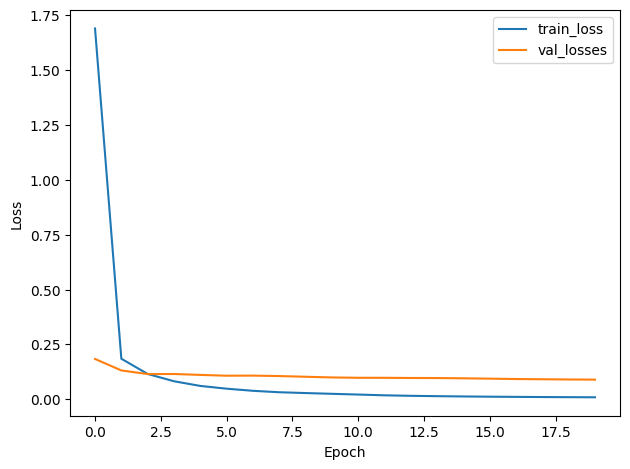

In [16]:
# TODO : train your CNN
np.random.seed(42)

model = CNN(input_dims=processed_data.shape[1:], 
            CNN_layers=[64], 
            FC_layers=[10],
            kernel_size=3,
            stride=1,
            padding="valid")

## Optimization parameters
lr = 0.03
num_epochs = 20

train_data, train_labels = train_set
val_data, val_lables = val_set

train_losses, val_losses, best_model, best_loss= train(model=model,
                                                        train_data=train_data,
                                                        train_labels=train_labels,
                                                        val_data=val_data,
                                                        val_labels=val_lables,
                                                        n_classes=10,
                                                        lr=lr,
                                                        num_epochs=num_epochs)

print(f"Best model loss {best_loss:.4f}")

plt.figure()
plt.plot(range(num_epochs), train_losses, label="train_loss")
plt.plot(range(num_epochs), val_losses, label="val_losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation 

It's time to evaluate your model on your test data. You should compute the accuracy and recall per class. The code from the previous lab should work.
You can also compute and show the confusion matrix.

In [17]:
## TODO : evaluate the model's accuracy and recall per class on the TEST set. 
## (optional) : compute and plot the confusion matrix
def test(model, test_data, test_labels, n_classes=10) :
    accuracy = 0
    true_pos, false_neg = np.zeros(n_classes), np.zeros(n_classes)
    all_preds = [
        
    ]
    for X, y in tqdm(zip(test_data, test_labels), desc="Testing"):
        logits = model(X)
        prob_preds = softmax(logits)
        y_pred = np.argmax(prob_preds, axis=1)
        accuracy += 1 if y_pred == y else 0
        
        if y_pred == y:
            true_pos[y] += 1
        else:
            false_neg[y] += 1

        all_preds.append(y_pred)

    accuracy /= len(test_data)
    recall = true_pos / (true_pos + false_neg)
    recall = {i:round(i_recall*100, 2) for i, i_recall in enumerate(recall)}
    
    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print(f"Test Recall: {recall}")
    
    cm = confusion_matrix(test_labels, all_preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (test set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return accuracy, recall

Testing: 270it [00:07, 34.72it/s]


Test Accuracy: 96.67%
Test Recall: {0: 100.0, 1: 100.0, 2: 100.0, 3: 90.0, 4: 100.0, 5: 100.0, 6: 94.74, 7: 88.46, 8: 96.15, 9: 93.1}


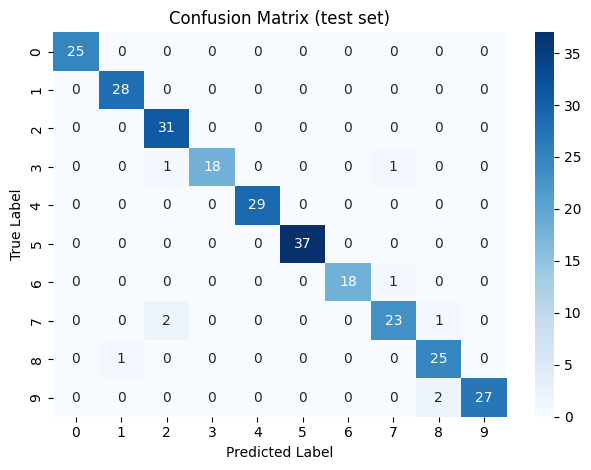

In [18]:
test_data, test_labels = test_set
test_acc, test_recall = test(model=best_model,
                             test_data=test_data,
                             test_labels=test_labels,
                             n_classes=10)